In [36]:
import importlib
import NeuralNetwork

importlib.reload(NeuralNetwork)
from NeuralNetwork import NeuralNetwork

import torch
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn as nn

In [37]:
# Define a transform to convert images to PyTorch tensors
transform = transforms.ToTensor()

# Download and load the training set
train_dataset = datasets.EMNIST(
    root="./data",       # where to store the data
    split="digits",      # "digits" for 0–9, other options: "letters", "balanced", etc.
    train=True,
    download=True,
    transform=transform
)

# Download and load the test set
test_dataset = datasets.EMNIST(
    root="./data",
    split="digits",
    train=False,
    download=True,
    transform=transform
)

In [38]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

In [39]:
# Create a DataLoader for batching
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=64)

In [40]:
# Create model and train
model = NeuralNetwork()
metrics = model.train_model(train_loader=train_loader, val_loader=val_loader, epochs=1)

Epoch 1/1: 100%|██████████| 3750/3750 [00:22<00:00, 169.38it/s]


In [41]:
print(metrics)

       train_loss  val_loss   val_acc
epoch                                
1        0.178265  0.128206  0.966021


In [42]:
train_acc = model.accuracy(train_loader)
val_acc = model.accuracy(val_loader)
test_acc = model.accuracy(test_loader)

100%|██████████| 625/625 [00:02<00:00, 246.38it/s]


In [43]:
print(f"Train: {(train_acc*100):.2f}%, Validation: {(val_acc*100):.2f}%, Test: {(test_acc*100):.2f}%")

Train: 96.69%, Validation: 96.60%, Test: 96.39%


In [44]:
preds = model.predict(test_loader)

y_true = []
for _, y_batch in test_loader:
    y_true.append(y_batch)
y_true = torch.cat(y_true)

100%|██████████| 625/625 [00:02<00:00, 250.00it/s]


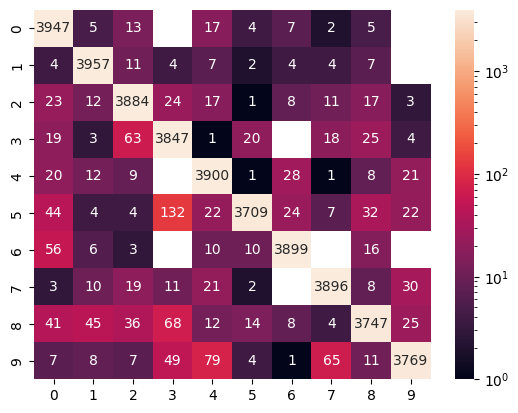

In [45]:
from matplotlib.colors import LogNorm

cm = confusion_matrix(y_true, preds)
sns.heatmap(cm, norm=LogNorm(), annot=True, fmt='d')
plt.show()

# Extracting Parameters

In [46]:
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [47]:
for name, param in model.named_parameters():
    print(name, param.shape)

linear_relu_stack.0.weight torch.Size([512, 784])
linear_relu_stack.0.bias torch.Size([512])
linear_relu_stack.2.weight torch.Size([256, 512])
linear_relu_stack.2.bias torch.Size([256])
linear_relu_stack.4.weight torch.Size([10, 256])
linear_relu_stack.4.bias torch.Size([10])


In [48]:
layers = {}

for name, module in model.named_modules():
    if isinstance(module, nn.Linear):
        layers[name] = {
            "weight": module.weight,
            "bias": module.bias
        }

In [49]:
# Example access
for name, params in layers.items():
    print(name)
    print("  weight:", params["weight"].shape)
    print("  bias:", params["bias"].shape)

linear_relu_stack.0
  weight: torch.Size([512, 784])
  bias: torch.Size([512])
linear_relu_stack.2
  weight: torch.Size([256, 512])
  bias: torch.Size([256])
linear_relu_stack.4
  weight: torch.Size([10, 256])
  bias: torch.Size([10])


In [50]:
batch = next(iter(test_loader))
inputs, labels = batch

In [53]:
a = model.get_activations(test_loader)

In [52]:
print(a.keys())

dict_keys(['flatten', 'layer_0_Linear', 'layer_1_ReLU', 'layer_2_Linear', 'layer_3_ReLU', 'layer_4_Linear'])
